Importing libraries and datasets:

In [1]:
import pandas as pd
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import numpy as np

mh = pd.read_csv('data/cleaned_mental_health_data.csv', parse_dates=['Timestamp'])
music = pd.read_csv('data/processed_music_data.csv')

### K-S Test

Below we will use a two-sample K-S test to check whether the distribution of mental health reports across months matches the distribution of listening habits across months. 

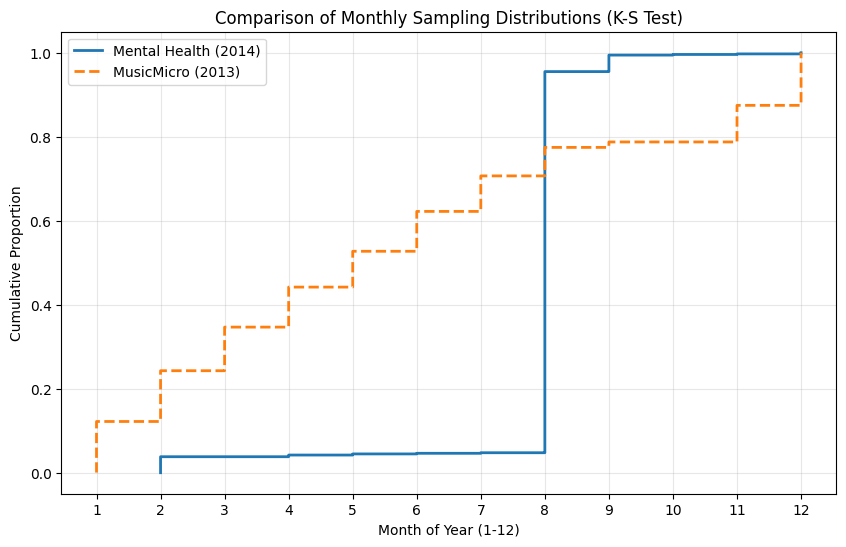

Our p-value is: 0.0


In [2]:
mh_months = mh['Timestamp'].dt.month
music_months = music['month']

ks_stat, p_val = ks_2samp(mh_months, music_months)

def get_ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x, y

x_mh, y_mh = get_ecdf(mh_months)
x_music, y_music = get_ecdf(music_months)

plt.figure(figsize=(10, 6))
plt.step(x_mh, y_mh, label='Mental Health (2014)', where='post', linewidth=2)
plt.step(x_music, y_music, label='MusicMicro (2013)', where='post', linestyle='--', linewidth=2)

plt.title('Comparison of Monthly Sampling Distributions (K-S Test)')
plt.xlabel('Month of Year (1-12)')
plt.ylabel('Cumulative Proportion')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Our p-value is: {p_val}")

As you can see above, our p-value is 0 and there appears to be a large spike in entries in the 8th month, August. As you can see below, there is a class imbalance in the mental health dataset where a vast majority of entries come from August.

In [3]:
mh.value_counts('Month')

Month
8     265316
9      11486
2      11140
4       1170
12       824
5        780
10       434
6        434
11       390
7        390
Name: count, dtype: int64

To try and fix this class imbalance, we will attempt to uniformly randomly downsample our data so that there are more equal amounts across months. This will ensure that each month carries roughly similar weight in the ECDF.

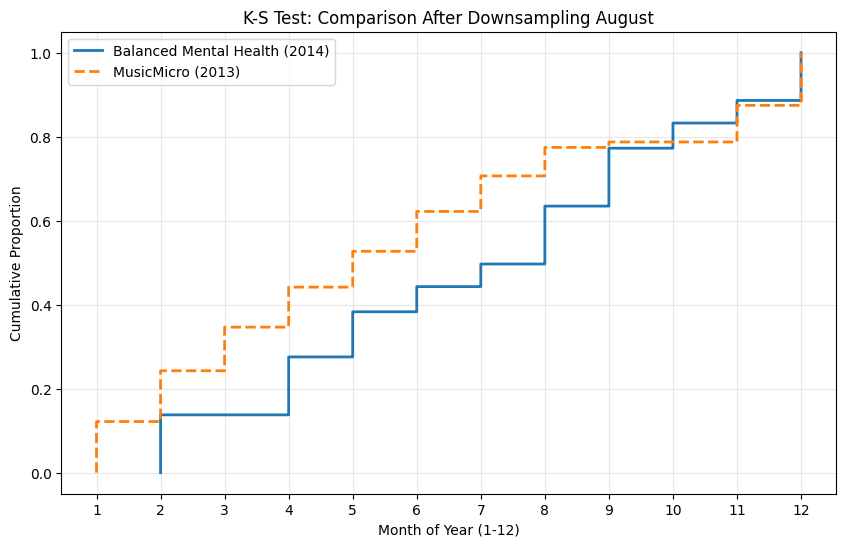

Our new p-value: 3.267024646590727e-76


In [4]:
mh['month'] = mh['Timestamp'].dt.month

target_n = 1000 
mh_balanced = mh.groupby('month').apply(
    lambda x: x.sample(n=min(len(x), target_n), random_state=42)
).reset_index(drop=True)

ks_stat, p_val = ks_2samp(mh_balanced['Month'], music['month'])

def get_ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x, y

x_mh, y_mh = get_ecdf(mh_balanced['Month'])
x_music, y_music = get_ecdf(music['month'])

plt.figure(figsize=(10, 6))
plt.step(x_mh, y_mh, label='Balanced Mental Health (2014)', where='post', linewidth=2)
plt.step(x_music, y_music, label='MusicMicro (2013)', where='post', linestyle='--', linewidth=2)

plt.title('K-S Test: Comparison After Downsampling August')
plt.xlabel('Month of Year (1-12)')
plt.ylabel('Cumulative Proportion')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Our new p-value: {p_val}")

Despite out efforts, our p-value is still incredibly small, meaning we REJECT the null hypothesis that these two datasets come from the same distribution. If we altered the dataset any more we would run the risk of manipulating the data too much to fit what we're looking for. 